Práctica de conceptos básicos:

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
s = pd.Series([1, 2, 3])
s.loc[0] = None
s

,0
0,NaN
1,2.00
2,3.00


In [ ]:
s = pd.Series(["a", "b", "c"])
s.loc[0] = None
s.loc[1] = np.nan
s

,0
0,None
1,NaN
2,c


Carga de las librerías para trabajar:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')
import plotly.express as px
import numpy
import pandas

# import cufflinks as cf
# import plotly.graph_objs as go
# import chart_studio.plotly as py

# Make Plotly work in your Jupyter Notebook
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
# Use Plotly locally
# cf.go_offline()

%matplotlib inline


Cargar los datos:

In [ ]:
import os
import pandas as pd

# Definición de la ruta relativa dentro del repositorio
data_dir = "data"
data_path = os.path.join(data_dir, "melb_data.csv")

# Verificación y descarga automática en caso de ejecución en entornos efímeros (como Google Colab)
if not os.path.exists(data_path):
    os.makedirs(data_dir, exist_ok=True)
    print("Descargando dataset para asegurar reproducibilidad...")
    # URL del repositorio donde se alojará el archivo raw
    url = "https://raw.githubusercontent.com/tu_usuario/tu_repositorio/main/data/melb_data.csv"
    import urllib.request
    urllib.request.urlretrieve(url, data_path)

# Carga del dataset
data = pd.read_csv(data_path)
print(f"Dataset cargado exitosamente. Dimensiones: {data.shape}")

Mounted at /content/drive


Analizar los datos del archivo:

In [ ]:
melb_data.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [ ]:
y = melb_data.sample(10,random_state=123)
print(y)

              Suburb              Address  Rooms Type      Price Method  \
5799        St Kilda  25/69 Wellington St      2    u  542500.00     PI   
10596   Broadmeadows          48 Walsh St      3    h  386000.00      S   
7471      Ascot Vale         17 Monash St      3    h 1230000.00     PI   
2308          Elwood    2/129 Brighton Rd      2    u  684000.00     SP   
2602   Fitzroy North        264 Barkly St      3    h 1600000.00      S   
3159        Hawthorn           16 Pine St      3    h 1712000.00      S   
5781        St Kilda   1/62 Wellington St      1    u  500000.00     SP   
2443        Essendon      1/19 Cameron Rd      2    u  691000.00     SP   
6005        Sunshine        165 Morris St      3    h  591500.00      S   
6365          Toorak    4/264 Williams Rd      2    u  810000.00     SP   

             SellerG        Date  Distance  Postcode  ...  Bathroom  Car  \
5799         McGrath  10/09/2016      6.10   3182.00  ...      1.00 1.00   
10596  hockingstuart  

In [ ]:
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

Detección de las variables del dataset:

In [ ]:
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]

,0
Distance,6
Bedroom2,16
Bathroom,34
Car,1026
Landsize,1939
BuildingArea,17


Exploración de las variables "BEDROOM2, BATHROOM Y DISTANCE"


<Axes: xlabel='Bedroom2', ylabel='Type'>

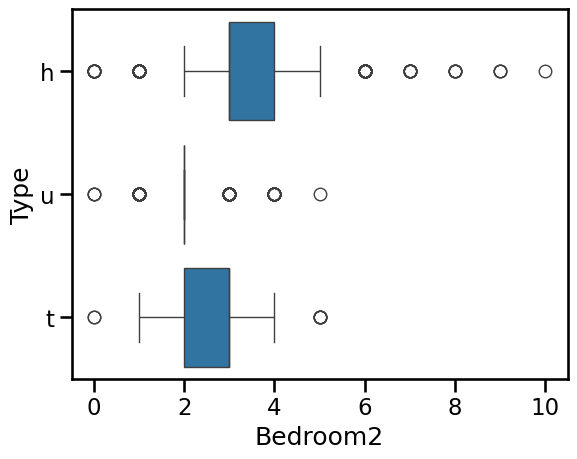

In [ ]:
sns.boxplot(data = melb_data[melb_data.Bedroom2 < 20], x = 'Bedroom2', y = 'Type')

In [ ]:
Bedroom2 = melb_data.Bedroom2
Rooms = melb_data.Rooms
pd.crosstab(Bedroom2, Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.00,0,5,8,3,0,0,0,0,0
1.00,663,21,5,2,0,0,0,0,0
2.00,16,3539,162,19,1,0,0,0,0
3.00,2,74,5626,175,18,1,0,0,0
4.00,0,8,73,2473,42,4,0,1,0
5.00,0,1,5,15,531,2,2,0,0
6.00,0,0,0,0,2,59,0,2,0
7.00,0,0,0,0,1,1,8,0,0
8.00,0,0,0,0,1,0,0,4,0


La variable "Rooms" es mucho más informativa que la variable Bedroom2

In [ ]:
melb_df = melb_data.copy()
melb_df = melb_df.drop(['Bedroom2'], axis=1)
melb_df.sample(10, random_state = 123)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
5799,St Kilda,25/69 Wellington St,2,u,542500.00,PI,McGrath,10/09/2016,6.10,3182.00,1.00,1.00,0.00,NaN,NaN,Port Phillip,-37.86,144.99,Southern Metropolitan,13240.00
10596,Broadmeadows,48 Walsh St,3,h,386000.00,S,hockingstuart,8/07/2017,14.00,3047.00,1.00,1.00,341.00,71.00,1965.00,Hume,-37.69,144.92,Northern Metropolitan,4294.00
7471,Ascot Vale,17 Monash St,3,h,1230000.00,PI,Nelson,20/05/2017,5.90,3032.00,1.00,2.00,538.00,NaN,NaN,Moonee Valley,-37.78,144.91,Western Metropolitan,6567.00
2308,Elwood,2/129 Brighton Rd,2,u,684000.00,SP,McGrath,19/11/2016,7.70,3184.00,1.00,0.00,0.00,98.00,1930.00,Port Phillip,-37.88,144.99,Southern Metropolitan,8989.00
2602,Fitzroy North,264 Barkly St,3,h,1600000.00,S,Collins,25/02/2017,3.50,3068.00,1.00,0.00,370.00,NaN,NaN,Yarra,-37.78,144.99,Northern Metropolitan,6244.00
3159,Hawthorn,16 Pine St,3,h,1712000.00,S,Marshall,12/11/2016,4.60,3122.00,1.00,1.00,342.00,130.00,1900.00,Boroondara,-37.81,145.02,Southern Metropolitan,11308.00
5781,St Kilda,1/62 Wellington St,1,u,500000.00,SP,Biggin,4/03/2017,6.10,3182.00,1.00,1.00,2335.00,58.00,2002.00,Port Phillip,-37.86,144.99,Southern Metropolitan,13240.00
2443,Essendon,1/19 Cameron Rd,2,u,691000.00,SP,Brad,25/02/2017,8.00,3040.00,1.00,1.00,201.00,80.00,1995.00,Moonee Valley,-37.75,144.93,Western Metropolitan,9264.00
6005,Sunshine,165 Morris St,3,h,591500.00,S,Barry,30/07/2016,12.60,3020.00,1.00,2.00,427.00,NaN,NaN,Brimbank,-37.79,144.83,Western Metropolitan,3755.00
6365,Toorak,4/264 Williams Rd,2,u,810000.00,SP,Jellis,10/12/2016,4.60,3142.00,2.00,2.00,0.00,94.00,1980.00,Stonnington,-37.84,145.00,Southern Metropolitan,7217.00


<Axes: xlabel='Bathroom', ylabel='Type'>

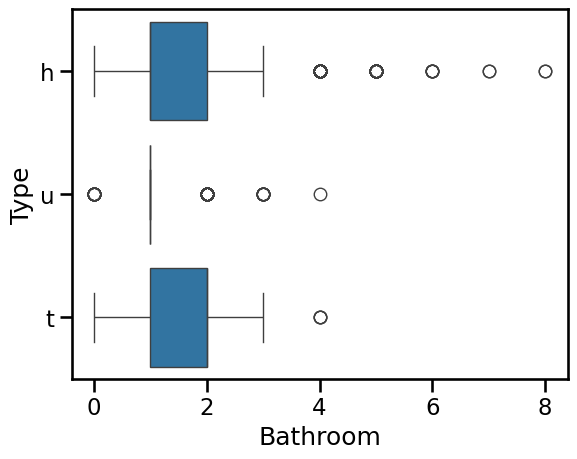

In [ ]:
sns.boxplot(data = melb_data, x = 'Bathroom', y = 'Type')

In [ ]:
Bathroom = melb_data.Bathroom
pd.crosstab(Bathroom, Rooms)

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.00,1,19,11,3,0,0,0,0,0
1.00,674,3117,3250,452,17,2,0,0,0
2.00,6,504,2459,1720,260,20,3,2,0
3.00,0,8,153,469,244,35,5,2,1
4.00,0,0,5,41,47,9,2,2,0
5.00,0,0,1,2,25,0,0,0,0
6.00,0,0,2,0,2,1,0,0,0
7.00,0,0,0,0,1,0,0,1,0
8.00,0,0,0,1,0,0,0,1,0


In [ ]:
import numpy as np
melb_df.loc[melb_df.Bathroom < 1, 'Bathroom'] = 1

cols2 = melb_df[melb_df == 0].count(axis=0)
cols2[cols2 > 0]


,0
Distance,6
Car,1026
Landsize,1939
BuildingArea,17


In [ ]:
cols[cols > 0]

,0
Distance,6
Bedroom2,16
Bathroom,34
Car,1026
Landsize,1939
BuildingArea,17


In [ ]:
melb_data.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [ ]:
melb_df.describe()

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,1.54,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,1.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [ ]:
cols = melb_data[melb_data == 0].count(axis=0)
cols[cols > 0]

,0
Distance,6
Bedroom2,16
Bathroom,34
Car,1026
Landsize,1939
BuildingArea,17


Reconocimiento de datos faltantes:

In [ ]:
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [ ]:
missing_values_count = melb_data.isna().sum()
missing_values_count

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [ ]:
melb_df.isna().sum()
missing_values_count = melb_df.isnull().sum()


In [ ]:
total_cells = np.prod(melb_data.shape)
total_missing = missing_values_count.sum()

# porcentaje de datos perdidos
print((total_missing/total_cells) * 100)

4.648292306613367


# **SEGUNDA PARTE**

<Axes: >

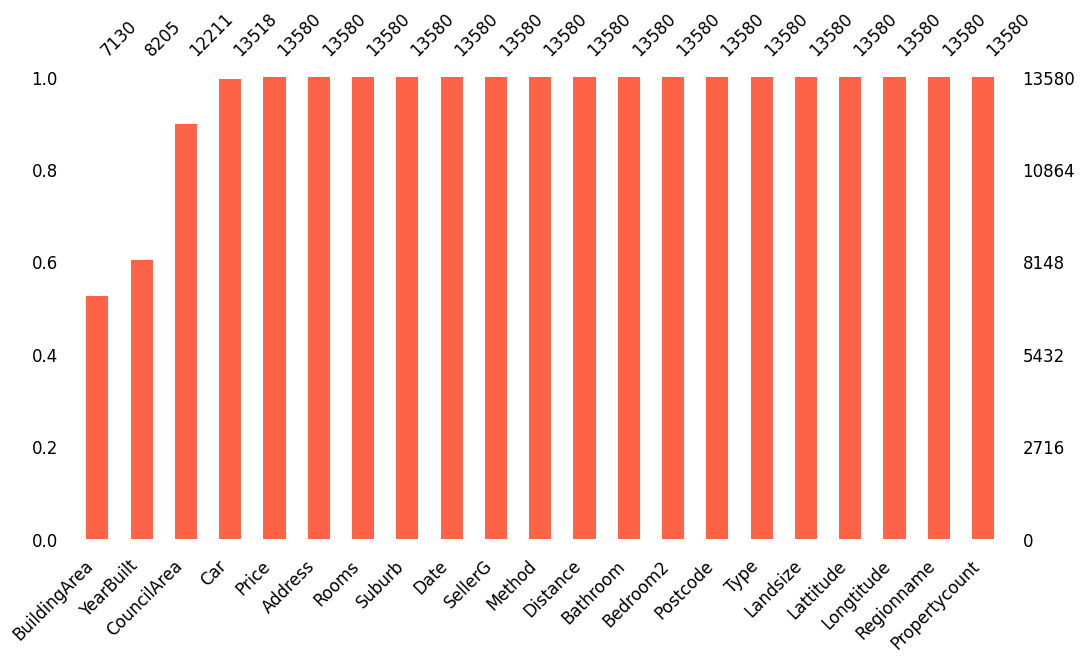

In [ ]:
import missingno as msno
msno.bar(melb_data, figsize=(12, 6), sort = "ascending", fontsize=12, color = 'tomato')

# color = 'steelblue'
# color = "dodgerblue"
# color = "tab:green"

<Axes: >

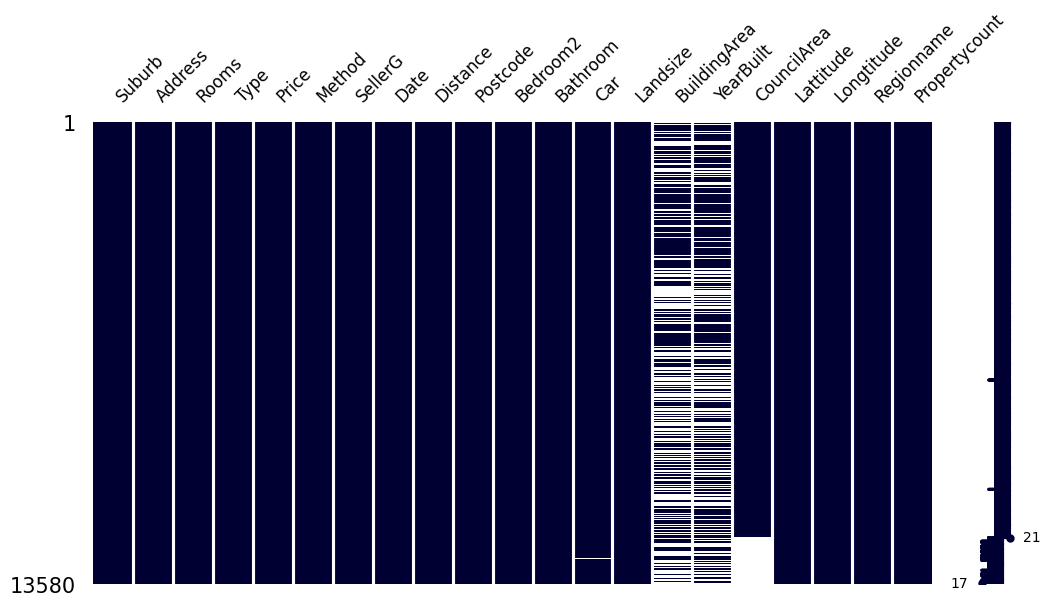

In [ ]:
msno.matrix(melb_data, figsize=(12, 6), fontsize=12, color = [0,0,0.2])

<Axes: >

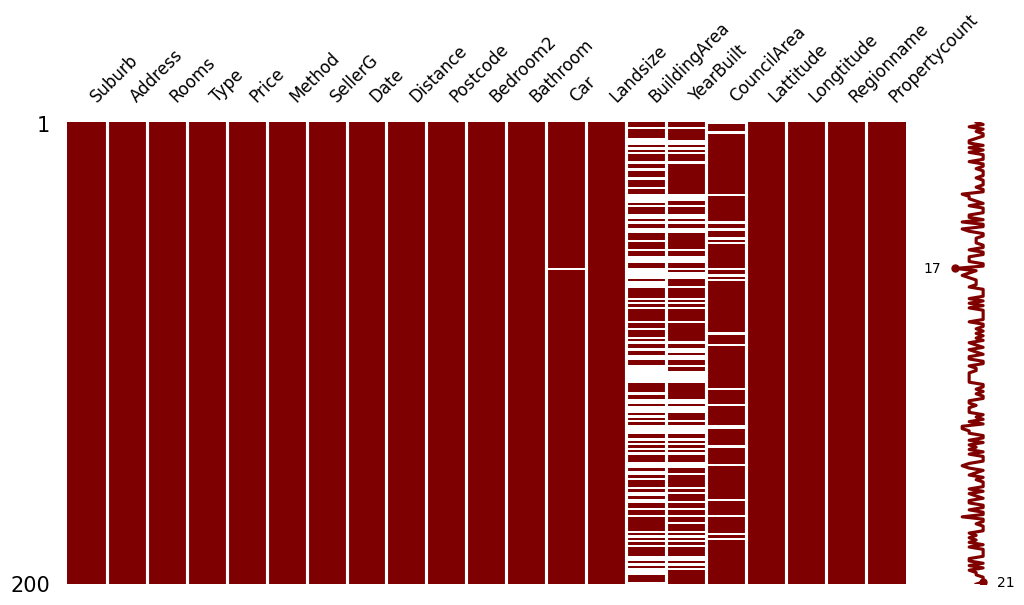

In [ ]:
msno.matrix(melb_data.sample(200), figsize=(12, 6), fontsize=12, color = [0.5,0,0])

In [ ]:
Car = melb_data.Car

fig = px.histogram(Car, nbins = 100, labels = {'value': 'Car', 'count': 'number of houses'},
                   marginal = 'violin', title = 'Distribution of home with car places in Melbourne',
                   color_discrete_sequence = px.colors.sequential.RdBu)

fig.update_layout(showlegend = False)
fig.show()

In [ ]:
Car = melb_data.Car
Type = melb_data.Type
pd.crosstab(Type, Car)

Car,0.00,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00
Type,,,,,,,,,,,
h,846,2681,4524,702,499,63,54,7,9,1,3
t,15,492,584,19,4,0,0,0,0,0,0
u,165,2336,483,27,3,0,0,1,0,0,0


<Axes: >

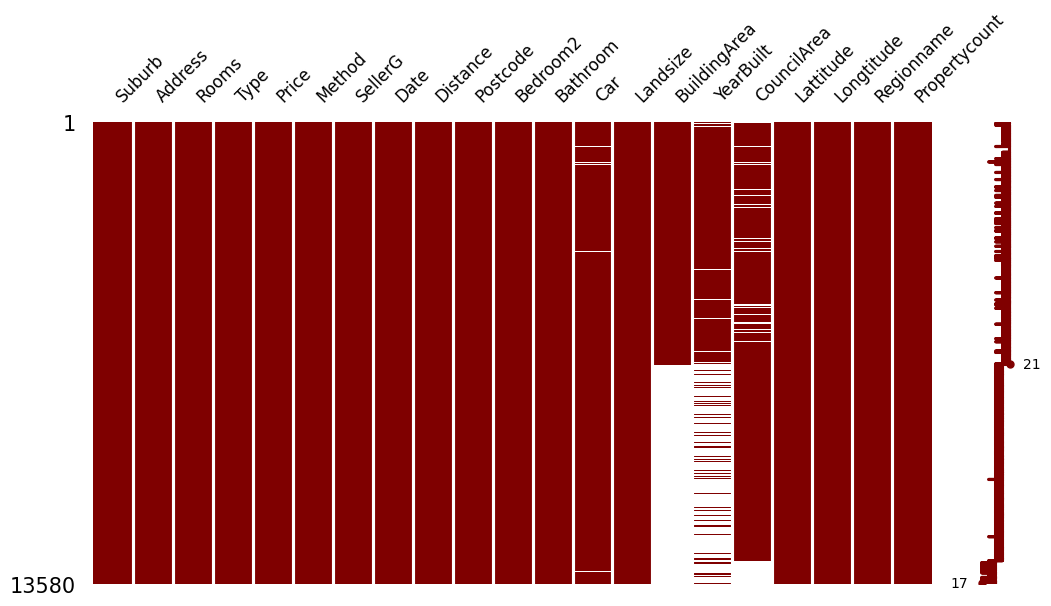

In [ ]:
sorted = melb_data.sort_values('BuildingArea')
msno.matrix(sorted, figsize = (12, 6), fontsize = 12, color = [0.5, 0, 0])

<Axes: >

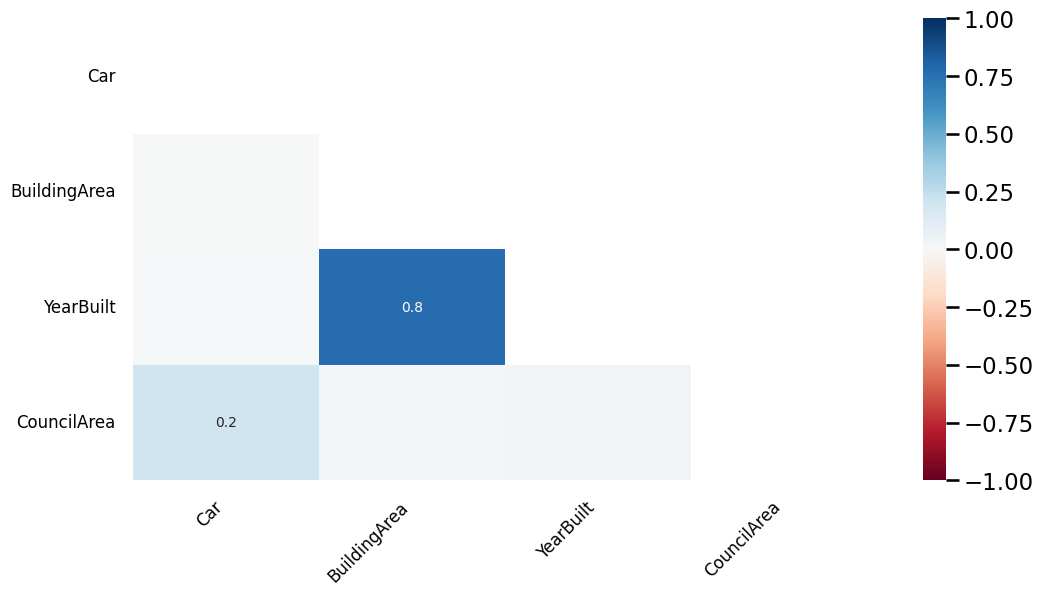

In [ ]:
msno.heatmap(melb_data, figsize = (12, 6), fontsize = 12)

In [ ]:
melb_df['Car'].mean()

np.float64(1.6100754549489569)

In [ ]:
melb_df.dropna(subset = ['Car'], how = 'any', inplace = True)
melb_df['Car'].isnull().sum()

np.int64(0)

<Axes: >

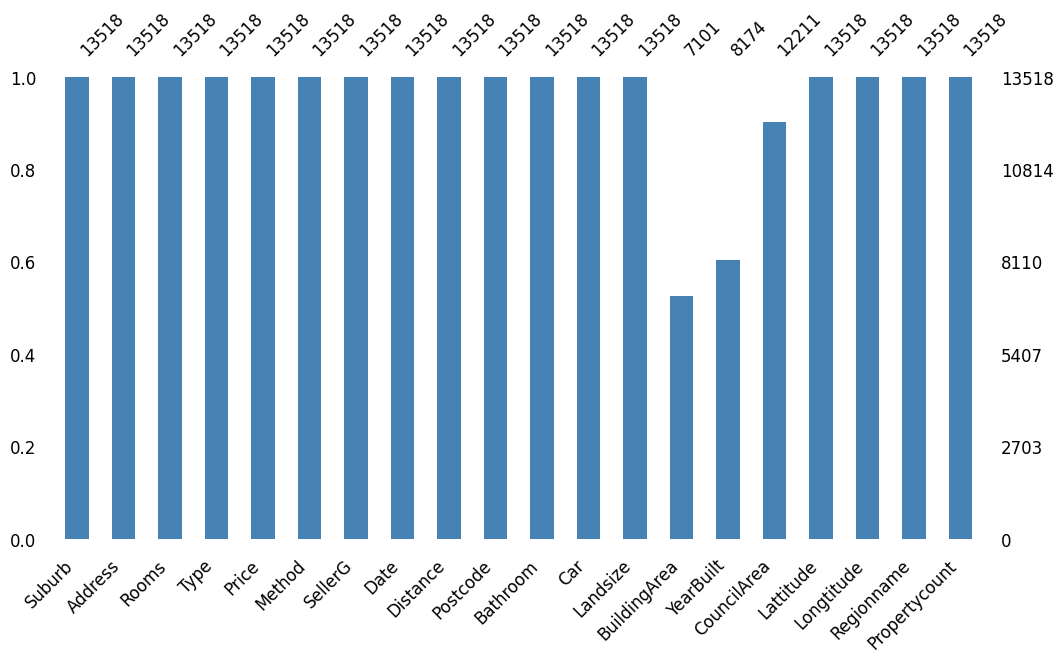

In [ ]:
msno.bar(melb_df, figsize = (12, 6), fontsize=12, color='steelblue')